LOADING THE DATASETS

In [ ]:
import  pandas as pd
df=pd.read_csv('/content/drive/MyDrive/final_dl_df.csv')

BILSTM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,461 (10.15 MB)

 Trainable params: 2,659,461 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12207/12207 ━━━━━━━━━━━━━━━━━━━━ 257s 20ms/step - accuracy: 0.4717 - loss: 1.2772 - val_accuracy: 0.5231 - val_loss: 1.1704
Epoch 2/20
12207/12207 ━━━━━━━━━━━━━━━━━━━━ 267s 21ms/step - accuracy: 0.5298 - loss: 1.1652 - val_accuracy: 0.5313 - val_loss: 1.1541
Epoch 3/20
12207/12207 ━━━━━━━━━━━━━━━━━━━━ 254s 21ms/step - accuracy: 0.5477 - loss: 1.1279 - val_accuracy: 0.5351 - val_loss: 1.1465
Epoch 4/20
12207/12207 ━━━━━━━━━━━━━━━━━━━━ 261s 20ms/step - accuracy: 0.5633 - loss: 1.0958 - val_accuracy: 0.5338 - val_loss: 1.1538
Epoch 5/20
12207/12207 ━━━━━━━━━━━━━━━━━━━━ 259s 21ms/step - accuracy: 0.5780 - loss: 1.0661 - val_accuracy: 0.5298 - val_loss: 1.1706
Epoch 6/20
12207/12207 ━━━━━━━━━━━━━━━━━━━━ 262s 21ms/step - accuracy: 0.5906 - loss: 1.0378 - val_accuracy: 0.5306 - val_loss: 1.1732
13563/13563 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step
Accuracy: 0.5347
Classification Report:

              precision    recall  f1-score   support

           1       0.64      0.68      0.66     

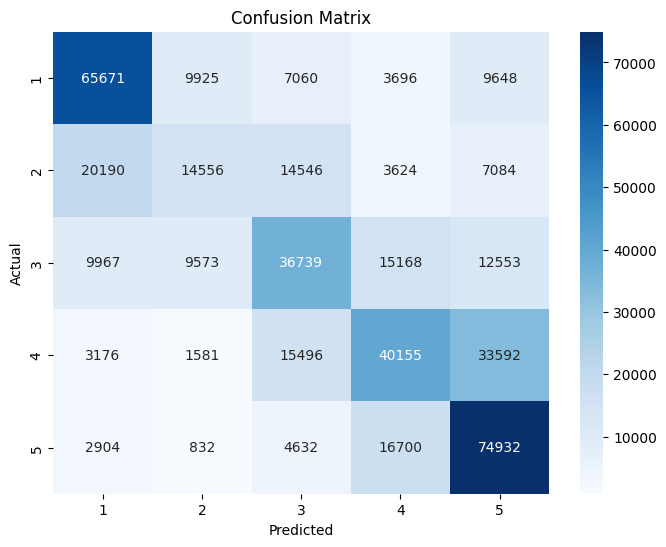

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Prepare data
df['review'] = df['review'].astype(str)

X = df['review']
y = df['rating']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    stratify=y_categorical,
    random_state=42
)

# Tokenization and padding
max_words = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


# Build BiLSTM Model
embedding_dim = 128
lstm_units = 64
num_classes = y_categorical.shape[1]

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
model.add(Bidirectional(LSTM(lstm_units)))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Build model to show correct summary
model.build(input_shape=(None, max_len))
model.summary()

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# ----------------------
# Train Model
# ----------------------
history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,callbacks=[early_stop]
)


# Evaluate Model
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Precision, Recall, F1-Score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in le.classes_]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

DISTILBERT

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification


# Prepare Data
df['review'] = df['review'].astype(str)
X = df['review']
y = df['rating']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Tokenization
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)
max_len = 150

train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=max_len)
test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=max_len)

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
)).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
)).batch(16)

# Build DistilBERT Model
model = TFDistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes
)

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = ['accuracy']

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# Train Model
history = model.fit(
    train_dataset,
    validation_data=test_dataset.take(int(len(test_dataset)*0.1)),  # simulate validation split
    epochs=5,
    callbacks=[early_stop]
)


# Evaluate Model
y_pred_logits = model.predict(test_dataset).logits
y_pred = np.argmax(y_pred_logits, axis=1)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in le.classes_]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
